Librarys:

- conda create -n "myenv" python=3.11
- conda install geopandas
- pip install jupyter

- pip install osmnx (https://osmnx.readthedocs.io/en/stable/)
- pip install networkx[default] (https://nx.dev/docs/concepts/buildable-and-publishable-libraries) -> evtl already satisfied


Visualisierung:

- pip install ipywidgets
- conda install -c conda-forge keplergl
- pip install setuptools==80.9.0 --force-reinstall


In [1]:
# Falls nötig vorhher installieren

import geopandas as gpd
import osmnx as ox
import pyproj
import json

from shapely.geometry import LineString

from ipyleaflet import (
    Map,
    GeoJSON,
    Marker,
    Polyline,
    basemaps
)

In [ ]:
# Strassennetz Herunterladen -> bereits nur herunterladen aus polygon
place = "Zürich, Schweiz"
G_4326 = ox.graph.graph_from_place(place, network_type="bike", simplify=True)      # network_type "bike" oder "all" verwenden
G_4326

In [ ]:
# Graph in WebMercator (EPSG 3857) (Projektion, Meter) 

G_3857 = ox.project_graph(G_4326)


In [ ]:
# als gpdf speichern (pro EPSG)
nodes_4326, edges_4326 = ox.graph_to_gdfs(G_4326)
nodes_3857, edges_3857 = ox.graph_to_gdfs(G_3857)

#print(nodes_4326.head(5))
print(nodes_3857.head(5))

                       y              x  street_count highway junction  ref  \
osmid                                                                         
453801      5.248124e+06  462916.045266             3     NaN      NaN  NaN   
1990946417  5.248120e+06  462914.947545             3     NaN      NaN  NaN   
1229170106  5.248539e+06  463055.377372             3     NaN      NaN  NaN   
453805      5.248075e+06  462895.213594             4     NaN      NaN  NaN   
5132952919  5.248059e+06  462928.437799             3     NaN      NaN  NaN   

           railway                   geometry  
osmid                                          
453801         NaN  POINT (4.63e+05 5.25e+06)  
1990946417     NaN  POINT (4.63e+05 5.25e+06)  
1229170106     NaN  POINT (4.63e+05 5.25e+06)  
453805         NaN  POINT (4.63e+05 5.25e+06)  
5132952919     NaN  POINT (4.63e+05 5.25e+06)  


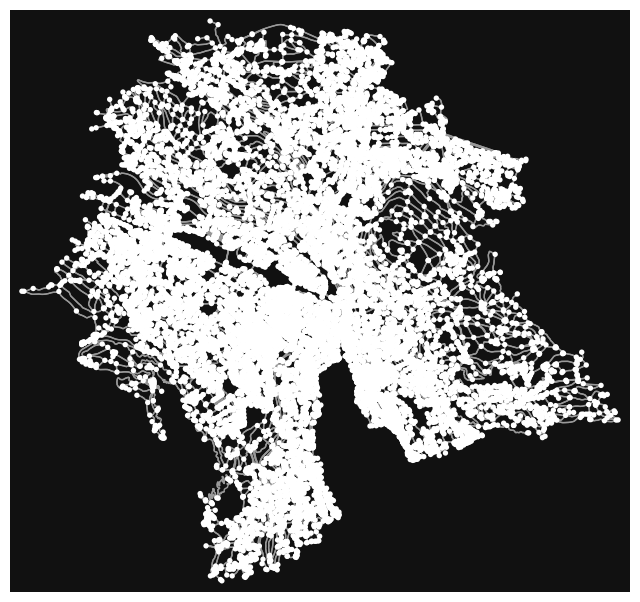

In [ ]:
# grafisch darstellen
fig, ax = ox.plot.plot_graph(
    G_4326,
    ax=None,  # optionally draw on pre-existing axis
    figsize=(8, 8),  # figure size to create if ax is None
    bgcolor="#111111",  # background color of the plot
    node_color="w",  # color of the nodes
    node_size=15,  # size of the nodes: if 0, skip plotting them
    node_alpha=None,  # opacity of the nodes
    node_edgecolor="none",  # color of the nodes' markers' borders
    node_zorder=1,  # zorder to plot nodes: edges are always 1
    edge_color="#999999",  # color of the edges
    edge_linewidth=1,  # width of the edges: if 0, skip plotting them
    edge_alpha=None,  # opacity of the edges
    show=True,  # if True, call pyplot.show() to show the figure
    close=False,  # if True, call pyplot.close() to close the figure
    save=False,  # if True, save figure to disk at filepath
    filepath=None,  # if save is True, the path to the file
    dpi=300,  # if save is True, the resolution of saved file
    bbox=None,  # bounding box to constrain plot
)

In [ ]:
# Karte Darstellen mit Jupyter Leaflet (Leaflet in Lat/Lon, 4326 ! Routing in WebMerc 3857 da Metrisch!)
# nur mal Grunddefinition, wird unten mit Funktionen ergänzt

center_lat = nodes_4326.geometry.y.mean()
center_lon = nodes_4326.geometry.x.mean()

m = Map(
    center=(center_lat, center_lon),
    zoom=13,
    basemap=basemaps.OpenStreetMap.Mapnik
)

edges_json = json.loads(edges_4326.to_json())
nodes_json = json.loads(nodes_4326.to_json())

hover_style = {
    "color": "yellow",
    "fillColor": "yellow",
    "fillOpacity": 1.0
}

edge_layer = GeoJSON(
    data=edges_json,
    style={
        "color": "gray",
        "weight": 1
    }
)

node_layer = GeoJSON(
    data=nodes_json,
    point_style={
        "radius": 3,
        "color": "blue",
        "fillColor": "blue",
        "fillOpacity": 0.8,
        "weight": 1
    },
    hover_style=hover_style
)


m.add_layer(edge_layer)
m.add_layer(node_layer)

#m      # aktivieren um Karte bereits hier anzuzeigen

In [ ]:
# leere Listen für def handle click und create bridge definieren
clicked_lines = []
clicked_points = []
clicked_markers = []
created_edges = []

In [ ]:
def create_bridge(click1, click2):

    # Klicks von WGS84 -> projiziertes CRS (WebMerc 3857) transformieren

    transformer = pyproj.Transformer.from_crs(
        "EPSG:4326",
        G_3857.graph["crs"],
        always_xy=True
    )

    x1, y1 = transformer.transform(click1[1], click1[0])
    x2, y2 = transformer.transform(click2[1], click2[0])

    # Nearest Nodes im projizierten Graphen

    node1 = ox.distance.nearest_nodes(
        G_3857,
        x1,
        y1
    )

    node2 = ox.distance.nearest_nodes(
        G_3857,
        x2,
        y2
    )

    # Koordinaten holen (projiziert -> Meter) für Längenberechung (Kosten)

    p1_3857 = (
        G_3857.nodes[node1]["x"],
        G_3857.nodes[node1]["y"]
    )

    p2_3857 = (
        G_3857.nodes[node2]["x"],
        G_3857.nodes[node2]["y"]
    )

    # Länge korrekt berechnen

    line_3857 = LineString([p1_3857, p2_3857])

    length = line_3857.length

    # Zurücktransformieren nach WGS84
    #    (für Darstellung auf Leaflet)

    reverse_transformer = pyproj.Transformer.from_crs(
        G_3857.graph["crs"],
        "EPSG:4326",
        always_xy=True
    )

    lon1, lat1 = reverse_transformer.transform(*p1_3857)
    lon2, lat2 = reverse_transformer.transform(*p2_3857)

    p1_4326 = (lon1, lat1)
    p2_4326 = (lon2, lat2)

    line_4326 = LineString([p1_4326, p2_4326])

    # Edge im projizierten Graphen hinzufügen

    G_3857.add_edge(
        node1,
        node2,
        length=float(length),
        geometry=line_3857,
        custom_edge=True
    )

    created_edges.append((G_3857, node1, node2))

    G_3857.add_edge(
        node2,
        node1,
        length=float(length),
        geometry=LineString([p2_3857, p1_3857]),
        custom_edge=True
    )

    created_edges.append((G_3857, node2, node1))


    # Edge zusätzlich im 4326 Graphen
    #    für Kartenanzeige

    G_4326.add_edge(
        node1,
        node2,
        length=float(length),
        geometry=line_4326,
        custom_edge=True
    )

    created_edges.append((G_4326, node1, node2))

    G_4326.add_edge(
        node2,
        node1,
        length=float(length),
        geometry=LineString([p2_4326, p1_4326]),
        custom_edge=True
    )

    created_edges.append((G_4326, node2, node1))

    # Linie auf Karte anzeigen  (! Leaflet erwartet Lat, Lon -> gpdf arbeitet mit Lon, Lat!)

    bridge_line = Polyline(
        locations=[
        (lat1, lon1),
        (lat2, lon2)
        ],
        color="red",
        weight=5
    )

    clicked_lines.append(bridge_line)

    m.add_layer(bridge_line)

In [ ]:
def handle_click(**kwargs):     #kwargs = key-word-arguments

    # Nur echte Klicks verarbeiten
    if kwargs.get("type") != "click":
        return

    # Alte Marker/Linien/Edges entfernen
    if len(clicked_points) == 0:

        for marker in clicked_markers:
            m.remove_layer(marker)

        clicked_markers.clear()

        for line in clicked_lines:
            m.remove_layer(line)

        clicked_lines.clear()

        for graph, u, v in created_edges:

            if graph.has_edge(u, v):
                graph.remove_edge(u, v)

        created_edges.clear()

    # Klickkoordinaten
    lat, lon = kwargs.get("coordinates")

    # Punkt speichern, Marker sezten
    clicked_points.append((lat, lon))

    marker = Marker(location=(lat, lon))

    clicked_markers.append(marker)

    m.add_layer(marker)

    # Sobald zwei Punkte vorhanden, funktion von oben aufrufen
    if len(clicked_points) == 2:

        create_bridge(
            clicked_points[0],
            clicked_points[1]
        )

        # Punkte zurücksetzen
        clicked_points.clear()


In [ ]:
# click Handler auf Interaktion (click) zu Karte hinzufügen
m.on_interaction(handle_click)

In [ ]:
# karte Anzeigen und Funktionen Ausführen (Brücken Bauen ;)
# Jeweils eine Brücke aufs Mal, auch mehrer möglich -> Funktion handle click anpassen

m

Map(center=[47.381581824373356, 8.530516068631039], controls=(ZoomControl(options=['position', 'zoom_in_text',…

In [ ]:
# Prüfung ob nur die letze Edge gespeichert wird, und nicht alle
new_nodes_3857, new_edges_3857 = ox.graph_to_gdfs(G_3857)


print(
    new_edges_3857.loc[
        new_edges_3857["custom_edge"].fillna(False)     # weil das ding nicht mit NaN werten umgehen kann
    ]
)


                          osmid highway lanes maxspeed name oneway reversed  \
u          v          key                                                     
6819488992 3248044180 0     NaN     NaN   NaN      NaN  NaN    NaN      NaN   
3248044180 6819488992 0     NaN     NaN   NaN      NaN  NaN    NaN      NaN   

                               length bridge  \
u          v          key                      
6819488992 3248044180 0    323.486837    NaN   
3248044180 6819488992 0    323.486837    NaN   

                                                                    geometry  \
u          v          key                                                      
6819488992 3248044180 0    LINESTRING (4.63e+05 5.25e+06, 4.63e+05 5.25e+06)   
3248044180 6819488992 0    LINESTRING (4.63e+05 5.25e+06, 4.63e+05 5.25e+06)   

                          width service tunnel  ref access junction est_width  \
u          v          key                                                       
6819488

In [ ]:
# same same but in diffrent CRS

new_nodes_4326, new_edges_4326 = ox.graph_to_gdfs(G_4326)

new_edges_4326.to_file("new_edges_4326.geojson", driver="GeoJSON")

print(
    new_edges_4326.loc[
        new_edges_4326["custom_edge"].fillna(False)     # weil das ding nicht mit NaN werten umgehen kann
    ]
)

                          osmid highway lanes maxspeed name oneway reversed  \
u          v          key                                                     
3248044180 6819488992 0     NaN     NaN   NaN      NaN  NaN    NaN      NaN   
6819488992 3248044180 0     NaN     NaN   NaN      NaN  NaN    NaN      NaN   

                               length bridge  \
u          v          key                      
3248044180 6819488992 0    323.486837    NaN   
6819488992 3248044180 0    323.486837    NaN   

                                                            geometry service  \
u          v          key                                                      
3248044180 6819488992 0    LINESTRING (8.5128 47.387, 8.5102 47.385)     NaN   
6819488992 3248044180 0    LINESTRING (8.5102 47.385, 8.5128 47.387)     NaN   

                          tunnel  ref access width junction est_width  \
u          v          key                                               
3248044180 6819488992 0

weiteres Vorgehen:

- polyline in Karte wird gelöscht
- Edge im Graph wird nicht gelöscht!

-> wie kann ich nun genau diesen Edge (kompletter gpdf) auslesen und weiter verwenden?

-> evtl strasse/edge entfernen?

-> download polygon zuschneiden?